In [1]:
import torch
from torch import nn

class LayerNorm(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.shift = nn.Parameter(torch.zeros(cfg["hidden_size"]))
        self.scale = nn.Parameter(torch.ones(cfg["hidden_size"]))
        self.eps = 1e-5
    
    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        normalized_x = (x - mean) / torch.sqrt(var + self.eps)
        return self.scale * normalized_x + self.shift

class GELU(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        return 0.5 * x * (1 + torch.tanh(
        torch.sqrt(torch.tensor(2/torch.pi)) * (x + 0.044715 * torch.pow(x, 3))
            ))

class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(cfg["hidden_size"], 4*cfg["hidden_size"]),
            GELU(),
            nn.Linear(4*cfg["hidden_size"], cfg["hidden_size"])
        )
    def forward(self, x):
        return self.fc(x)

class MultiHeadAttention(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.head_dim = cfg["hidden_size"] // cfg["num_heads"]
        self.num_heads = cfg["num_heads"]
        self.w_q = nn.Linear(cfg["hidden_size"], cfg["hidden_size"], bias=cfg["qkv_bias"])
        self.w_k = nn.Linear(cfg["hidden_size"], cfg["hidden_size"], bias=cfg["qkv_bias"])
        self.w_v = nn.Linear(cfg["hidden_size"], cfg["hidden_size"], bias=cfg["qkv_bias"])
        self.w_o = nn.Linear(cfg["hidden_size"], cfg["hidden_size"], bias=cfg["qkv_bias"])
        self.dropout = nn.Dropout(cfg["drop_rate"])
        self.register_buffer("mask",
                torch.triu(torch.ones(cfg["context_size"], cfg["context_size"]), diagonal=1).bool()
        )
    
    def forward(self, x):
        b, t, c = x.size()
        q = self.w_q(x).view(b, t, self.num_heads, self.head_dim).transpose(1, 2)
        k = self.w_k(x).view(b, t, self.num_heads, self.head_dim).transpose(1, 2)
        v = self.w_v(x).view(b, t, self.num_heads, self.head_dim).transpose(1, 2)
        attn_scores = (q @ k.transpose(-2, -1)) / torch.sqrt(torch.tensor(self.head_dim, dtype=torch.float32))
        attn_scores = attn_scores.masked_fill(self.mask[:t, :t], float('-inf'))
        attn_weights = torch.softmax(attn_scores, dim=-1)
        attn_weights = self.dropout(attn_weights)
        attn_output = attn_weights @ v
        attn_output = attn_output.transpose(1, 2).contiguous().view(b, t, c)
        return self.w_o(attn_output)

class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.norm1 = LayerNorm(cfg)
        self.norm2 = LayerNorm(cfg)
        self.attn = MultiHeadAttention(cfg)
        self.dropout = nn.Dropout(cfg["drop_rate"])
        self.ffn = FeedForward(cfg)
    
    def forward(self, x):
        short_cut = x
        x = self.norm1(x)
        x = self.attn(x)
        x = self.dropout(x)
        x = x + short_cut

        short_cut = x
        x = self.norm2(x)
        x = self.ffn(x)
        x = self.dropout(x)
        x = x + short_cut
        return x

class GPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.embedding = nn.Embedding(cfg["vocab_size"], cfg["hidden_size"])
        self.pos_emb = nn.Embedding(cfg["context_size"], cfg["hidden_size"])
        self.drop = nn.Dropout(cfg["drop_rate"])
        self.blocks = nn.Sequential(
            *[TransformerBlock(cfg) for _ in range(cfg["num_layers"])]
        )
        self.final_norm = LayerNorm(cfg)
        self.out_head = nn.Linear(cfg["hidden_size"], cfg["vocab_size"], bias=False)
    
    def forward(self, idx):
        b, t = idx.size()
        token_emb = self.embedding(idx)  
        pos_emb = self.pos_emb(torch.arange(t, device=idx.device))  # (t, hidden_size)
        x = self.drop(token_emb + pos_emb) 
        x = self.blocks(x)  
        x = self.final_norm(x) 
        return self.out_head(x) 

def generate_text(model, idx, max_new_tokens, context_size):
    for _ in range(max_new_tokens):
        idx_used = idx[:, -context_size:]
        logits = model(idx_used)[:, -1, :] 
        next_token = torch.argmax(logits, dim=-1, keepdim=True)  
        idx = torch.cat([idx, next_token], dim=1)  
    return idx

GPT_CONFIG_124M = {
    "vocab_size": 50257,
    "context_size": 256,
    "num_layers": 12,
    "num_heads": 12,
    "hidden_size": 768,
    "drop_rate": 0.1,
    "qkv_bias": False,
}

In [2]:
torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.eval()

GPTModel(
  (embedding): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (drop): Dropout(p=0.1, inplace=False)
  (blocks): Sequential(
    (0): TransformerBlock(
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (attn): MultiHeadAttention(
        (w_q): Linear(in_features=768, out_features=768, bias=False)
        (w_k): Linear(in_features=768, out_features=768, bias=False)
        (w_v): Linear(in_features=768, out_features=768, bias=False)
        (w_o): Linear(in_features=768, out_features=768, bias=False)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (dropout): Dropout(p=0.1, inplace=False)
      (ffn): FeedForward(
        (fc): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
    )
    (1): TransformerBlock(
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (attn): MultiHeadAttention(
        (w

### 使用函数进行id与text的转换

In [ ]:
import tiktoken

def text_to_tokens(text, tokenizer):
    encoded = tokenizer.encode(text, allowed_special={"<|endoftext|>"})
    return torch.tensor(encoded, dtype=torch.long).unsqueeze(0) # 添加batch维度

def tokens_to_text(tokens, tokenizer):
    tokens = tokens.squeeze(0).tolist()  # 移除batch维度并转换为列表
    return tokenizer.decode(tokens)



In [4]:
tokenizer = tiktoken.get_encoding("gpt2")
start_text = "Once upon a time"
input_tokens = text_to_tokens(start_text, tokenizer)
generated_tokens = generate_text(model, input_tokens, max_new_tokens=10, context_size=GPT_CONFIG_124M["context_size"])
generated_text = tokens_to_text(generated_tokens, tokenizer)
print(f'start token: {input_tokens}')
print(f'generated text: {generated_text}')

start token: tensor([[7454, 2402,  257,  640]])
generated text: Once upon a timeı connectorsdemon Belief Elect marinesylum buried vowedAp


### 计算loss

In [5]:
text = ["The weather is nice today.", "The cat there is cute.", "I love programming in Python."]
tokens = [text_to_tokens(t, tokenizer) for t in text]
print(tokens)
inputs = torch.cat(tokens, dim=0)[:, :3]
targets = torch.cat(tokens, dim=0)[:, 1:4]
print(inputs)
print(targets)

[tensor([[ 464, 6193,  318, 3621, 1909,   13]]), tensor([[  464,  3797,   612,   318, 13779,    13]]), tensor([[   40,  1842,  8300,   287, 11361,    13]])]
tensor([[ 464, 6193,  318],
        [ 464, 3797,  612],
        [  40, 1842, 8300]])
tensor([[6193,  318, 3621],
        [3797,  612,  318],
        [1842, 8300,  287]])


In [6]:
with torch.no_grad():
    logits = model(inputs)
    print(logits.shape)
probas = torch.softmax(logits, dim=-1)
print(probas.shape)

torch.Size([3, 3, 50257])
torch.Size([3, 3, 50257])


In [7]:
token_idxs = torch.argmax(probas, dim=-1)
print(token_idxs)

tensor([[23335, 32860, 43555],
        [23335, 39217, 44535],
        [ 3831, 27854, 38521]])


In [8]:
targets[0].squeeze(0).shape

torch.Size([3])

In [9]:
target_text = [tokens_to_text(t, tokenizer) for t in targets]
output_text = [tokens_to_text(t, tokenizer) for t in token_idxs]
print(f'target text: {target_text}')
print(f'output text: {output_text}')

target text: [' weather is nice', ' cat there is', ' love programming in']
output text: ['mph convoyNev', 'mph awakened Visitors', ' Tur Coulinse']


In [10]:
tokenizer.decode([32860, 23335, 43555]) # 空格不是单独的token，有的token带空格，有的没有

' convoymphNev'

In [11]:
tp1 = probas[0, [0,1,2], targets[0].squeeze(0)]
tp2 = probas[1, [0,1,2], targets[1].squeeze(0)]
tp3 = probas[2, [0,1,2], targets[2].squeeze(0)]
print(tp1)
print(tp2)
print(tp3)
print(1/GPT_CONFIG_124M["vocab_size"])

tensor([1.1511e-05, 2.7641e-05, 2.1262e-05])
tensor([3.2530e-05, 1.7960e-05, 2.5218e-05])
tensor([3.7333e-05, 3.2329e-05, 1.0021e-05])
1.9897725689953638e-05


交叉熵

In [12]:
loss = - torch.mean(torch.log(torch.cat([tp1, tp2, tp3])))
print(loss)

tensor(10.7246)


In [13]:
torch.cat([tp1, tp2, tp3])

tensor([1.1511e-05, 2.7641e-05, 2.1262e-05, 3.2530e-05, 1.7960e-05, 2.5218e-05,
        3.7333e-05, 3.2329e-05, 1.0021e-05])

In [14]:
loss = nn.CrossEntropyLoss()(logits.view(-1, GPT_CONFIG_124M["vocab_size"]), targets.flatten())
print(loss)

tensor(10.7246)


### 划分数据集

In [15]:
import tiktoken
import torch
from torch.utils.data import Dataset, DataLoader

class GPTDatasetV1(Dataset):
    def __init__(self, text, tokenizer, max_length, stride):
        self.input_ids = []
        self.target_ids = []
        token_ids = tokenizer.encode(text)

        for i in range(0, len(token_ids)-max_length, stride):
            self.input_ids.append(torch.tensor(token_ids[i:i+max_length]))
            self.target_ids.append(torch.tensor(token_ids[i+1:i+max_length+1]))

    def __len__(self):
        return len(self.input_ids)

    def __getitem__(self, idx):
        return self.input_ids[idx], self.target_ids[idx]

def create_dataloader_v1(text, tokenizer_name='gpt2', max_length=256, stride=128, batch_size=32, 
                         shuffle=True, num_workers=0, drop_last=True):
    tokenizer = tiktoken.get_encoding(tokenizer_name)
    dataset = GPTDatasetV1(text, tokenizer, max_length, stride)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=shuffle, drop_last=drop_last, num_workers=num_workers)
    return dataloader

In [16]:
with open("the-verdict.txt", "r", encoding='utf-8') as f:
    text = f.read()

tot_len = len(text)
print(f"Total characters in text: {tot_len}")

Total characters in text: 20479


In [17]:
train_text = text[:int(0.9 * tot_len)]
val_text = text[int(0.9 * tot_len):]

train_loader = create_dataloader_v1(train_text, max_length=GPT_CONFIG_124M["context_size"], stride=256, batch_size=2)
val_loader = create_dataloader_v1(val_text, max_length=GPT_CONFIG_124M["context_size"], stride=256, batch_size=2, shuffle=False)
print(f"Number of training samples: {len(train_loader.dataset)}")
print(f"Number of validation samples: {len(val_loader.dataset)}")

Number of training samples: 18
Number of validation samples: 2


In [18]:
def calculate_loss(inputs, targets, model, device):
    inputs, targets = inputs.to(device), targets.to(device)
    logits = model(inputs)
    loss = nn.CrossEntropyLoss()(logits.flatten(0, 1), targets.flatten())
    return loss

def calculate_loss_batch(dataloader, model, device, num_batches=None):
    was_training = model.training # 自动管理模型状态
    model.eval()
    total_loss = 0.0
    if len(dataloader) == 0:
        return None
    elif num_batches is None:
        num_batches = len(dataloader)
    else:
        num_batches = min(num_batches, len(dataloader))
    with torch.no_grad():
        for i, (inputs, targets) in enumerate(dataloader):
            if i >= num_batches:
                break
            loss = calculate_loss(inputs, targets, model, device)
            total_loss += loss.item()
    if was_training:
        model.train()
    return total_loss / num_batches if num_batches > 0 else None


In [19]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
train_loss = calculate_loss_batch(train_loader, model, device)
val_loss = calculate_loss_batch(val_loader, model, device)
print(f"Average training loss (first 10 batches): {train_loss:.4f}")
print(f"Average validation loss (first 10 batches): {val_loss:.4f}")

Average training loss (first 10 batches): 10.9814
Average validation loss (first 10 batches): 10.9590


训练模型

In [20]:
def generate_text_and_print(model, text, tokenizer, device, max_new_tokens=20):
    was_training = model.training
    model.eval()
    encoded = text_to_tokens(text, tokenizer).to(device)
    generated_tokens = generate_text(model, encoded, max_new_tokens, context_size=GPT_CONFIG_124M["context_size"])
    generated_text = tokens_to_text(generated_tokens, tokenizer)
    print(f"Input text: {text}")
    print(f"Generated text: {generated_text}")
    if was_training:
        model.train()

def train_f(model, optimizer, train_loader, test_loader, epochs, device):
    model.to(device)
    model.train()
    train_losses, test_losses, track_tokens_seen = [], [], []
    tokens_seen  = 0
    for epoch in range(epochs):
        for inputs,targets in train_loader:
            tokens_seen += inputs.numel()
            inputs, targets = inputs.to(device), targets.to(device)
            optimizer.zero_grad()
            loss = calculate_loss(inputs, targets, model, device)
            loss.backward()
            optimizer.step()
        train_loss = calculate_loss_batch(train_loader, model, device)
        test_loss = calculate_loss_batch(test_loader, model, device)
        train_losses.append(train_loss)
        test_losses.append(test_loss)
        track_tokens_seen.append(tokens_seen)
        print(f"Epoch {epoch+1}: Train Loss = {train_loss:.4f}, Test Loss = {test_loss:.4f}")
        generate_text_and_print(model, "I looked about the spacious white-panelled room,", tokenizer,device)
    return  train_losses, test_losses, track_tokens_seen



In [21]:
model = GPTModel(GPT_CONFIG_124M)
optimizer = torch.optim.AdamW(model.parameters(), lr=4e-4, weight_decay=0.1)
train_losses, test_losses, track_tokens_seen = train_f(model, optimizer, train_loader, val_loader, epochs=10, device=device)

Epoch 1: Train Loss = 7.1519, Test Loss = 7.5091
Input text: I looked about the spacious white-panelled room,
Generated text: I looked about the spacious white-panelled room,,,,,,,,,,,,,,,, the,,,,
Epoch 2: Train Loss = 5.9491, Test Loss = 6.5622
Input text: I looked about the spacious white-panelled room,
Generated text: I looked about the spacious white-panelled room,.



















Epoch 3: Train Loss = 5.6439, Test Loss = 6.5454
Input text: I looked about the spacious white-panelled room,
Generated text: I looked about the spacious white-panelled room, and a--and a.














Epoch 4: Train Loss = 4.9737, Test Loss = 6.3927
Input text: I looked about the spacious white-panelled room,
Generated text: I looked about the spacious white-panelled room, and it--and a--and, and. Gisburn's the "I--and that
Epoch 5: Train Loss = 4.2565, Test Loss = 6.3544
Input text: I looked about the spacious white-panelled room,
Generated text: I looked about the spacious white-panelled room, an

In [22]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

def plot_losses(epochs_seen, tokens_seen, train_losses, val_losses):
    fig, ax1 = plt.subplots(figsize=(5,3))
    ax1.plot(epochs_seen, train_losses, label="Training loss")
    ax1.plot(epochs_seen, val_losses, linestyle="-.", label="Validation loss")
    ax1.set_xlabel("Epoches")
    ax1.set_ylabel("Loss")
    ax1.legend(loc='best')
    ax1.xaxis.set_major_locator(MaxNLocator(integer=True))  # 设置X轴主刻度为整数
    ax2 = ax1.twiny() # 与 ax1 共享相同的Y轴，但在顶部有一个独立的X轴
    ax2.plot(tokens_seen, train_losses, alpha=0) # 画一条透明的线来设置第二个X轴的范围
    ax2.set_xlabel("Tokens seen")
    
    fig.tight_layout()
    plt.show()

In [23]:
epoches_seen = torch.arange(0,10)
print(epoches_seen)

tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])


过拟合！

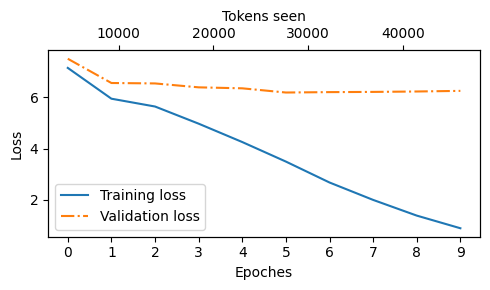

In [24]:
plot_losses(epoches_seen, track_tokens_seen, train_losses, test_losses)

temporature scaling

In [25]:
vocab = {
    "closer": 0,
    "every": 1,
    "effort": 2,
    "forward": 3,
    "inches": 4,
    "moves": 5,
    "pizza": 6,
    "toward": 7,
    "you": 8,
}
inverse_vocab = {v: k for k, v in vocab.items()}


In [26]:
next_token_logits = torch.tensor(
 [4.51, 0.89, -1.90, 6.75, 1.63, -1.62, -1.89, 6.28, 1.79]
)

In [27]:
next_idx = torch.argmax(next_token_logits).item()
print(f"Next token index: {next_idx}")
print(f"Next token: {inverse_vocab[next_idx]}")

Next token index: 3
Next token: forward


In [28]:
def print_sample_next_token(next_token_logits, inverse_vocab, sample_times):
    samples = [torch.multinomial(torch.softmax(next_token_logits, dim=-1), num_samples=1).item() for _ in range(sample_times)]
    results = torch.bincount(torch.tensor(samples))
    for idx, count in enumerate(results):
        token = inverse_vocab[idx]
        print(f"{token}: {count} times")

In [29]:
print_sample_next_token(next_token_logits, inverse_vocab, sample_times=1000)
probas = torch.softmax(next_token_logits, dim=-1)
proba_and_idx = {token:proba for token, proba in zip(vocab.keys(), probas)}
sorted_proba_and_idx = dict(sorted(proba_and_idx.items(), key=lambda item:item[1], reverse=True))
print('sorted probabilities:')
for token, proba in sorted_proba_and_idx.items():
    print(f"{token}: {proba:.4f}") 

# 显然这是依据概率进行的采样

closer: 70 times
every: 2 times
effort: 0 times
forward: 562 times
inches: 5 times
moves: 0 times
pizza: 0 times
toward: 358 times
you: 3 times
sorted probabilities:
forward: 0.5721
toward: 0.3576
closer: 0.0609
you: 0.0040
inches: 0.0034
every: 0.0016
moves: 0.0001
pizza: 0.0001
effort: 0.0001


大于1的temperature会使得采样更平均，反之使得采样更“尖锐”

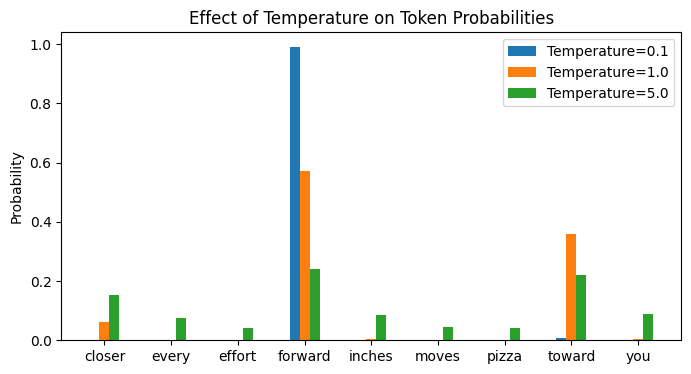

In [30]:
temperature = [0.1, 1.0, 5.0]
scaled_probas = [torch.softmax(next_token_logits / t, dim=-1) for t in temperature]

x = torch.arange(len(vocab))
bar_width = 0.15
fig, ax = plt.subplots(figsize=(8, 4))
for i, (t, scaled_proba) in enumerate(zip(temperature, scaled_probas)):
    plt.bar(x+i*bar_width, scaled_proba, width=bar_width, label=f'Temperature={t}')
ax.set_ylabel('Probability')
ax.set_xticks(x + bar_width)  # 设置X轴刻度位置
ax.set_xticklabels(vocab.keys())  # 设置X轴刻度标签
ax.legend()
plt.title('Effect of Temperature on Token Probabilities')
plt.show()

topk sampling

In [31]:
topk = 3
topk_logits, topk_pos = torch.topk(next_token_logits, topk)
print(f"Top-{topk} token indices: {topk_pos.tolist()}")
print(topk_logits)

Top-3 token indices: [3, 7, 0]
tensor([6.7500, 6.2800, 4.5100])


In [32]:
topk_masked_logits = torch.where(
    condition=next_token_logits < topk_logits[-1],
    input=torch.tensor(float('-inf')),
    other=next_token_logits  
)
print("Logits after top-k masking:")
print(topk_masked_logits)
print(f"Softmax probabilities after top-k masking:")
print(torch.softmax(topk_masked_logits, dim=-1))

Logits after top-k masking:
tensor([4.5100,   -inf,   -inf, 6.7500,   -inf,   -inf,   -inf, 6.2800,   -inf])
Softmax probabilities after top-k masking:
tensor([0.0615, 0.0000, 0.0000, 0.5775, 0.0000, 0.0000, 0.0000, 0.3610, 0.0000])


In [33]:
print_sample_next_token(topk_masked_logits, inverse_vocab, sample_times=1000)

closer: 52 times
every: 0 times
effort: 0 times
forward: 601 times
inches: 0 times
moves: 0 times
pizza: 0 times
toward: 347 times


In [34]:
def generate(model, idx, max_new_tokens, context_size, temperature=0.0, topk=None):
    is_training = model.training
    model.eval()
    for _ in range(max_new_tokens):
        idx_used = idx[:, -context_size:]
        with torch.no_grad():
            logits = model(idx_used)[:, -1, :]
        if topk is not None:
            topk_logits, _ = torch.topk(logits, topk)
            logits = torch.where(
                condition=logits < topk_logits[..., [-1]],
                input=torch.tensor(float('-inf')),
                other=logits
            )
        if temperature > 0.0:
            logits = logits / temperature
            next_token = torch.multinomial(torch.softmax(logits, dim=-1), num_samples=1)
            idx = torch.cat([idx, next_token], dim=1)
        else:
            next_token = torch.argmax(logits, dim=-1, keepdim=True)
            idx = torch.cat([idx, next_token], dim=1)
    if is_training:
        model.train()
    return idx
        
        


In [35]:
a = torch.randn(1,2,4)
a1,a2 = torch.topk(a, k=2) 
print(a1[:,:,-1].shape) 
print(a1[...,[-1]].shape)
print(a1[...,-1].shape)
print(a1[...,-1])
print(a1[...,[-1]])
print(a1[:,:,-1])

torch.Size([1, 2])
torch.Size([1, 2, 1])
torch.Size([1, 2])
tensor([[0.1275, 0.6252]])
tensor([[[0.1275],
         [0.6252]]])
tensor([[0.1275, 0.6252]])


In [36]:
a < a1[:,:,-1][:,:,None]

tensor([[[ True,  True, False, False],
         [ True,  True, False, False]]])

In [37]:
idx1 = generate(model,
                idx=text_to_tokens("I looked about the spacious white-panelled room,", tokenizer).to(device),
                max_new_tokens=20,
                context_size=GPT_CONFIG_124M["context_size"],
                temperature=2,
                topk=5
                )
print(tokens_to_text(idx1, tokenizer))

I looked about the spacious white-panelled room, for a smile behind down in a deprec of to my own to me!"

She glanced


In [38]:
idx2 = generate(model,
                idx=text_to_tokens("I looked about the spacious white-panelled room,", tokenizer).to(device),
                max_new_tokens=20,
                context_size=GPT_CONFIG_124M["context_size"],
                temperature=0,
                topk=5
                )
print(tokens_to_text(idx2, tokenizer))

I looked about the spacious white-panelled room, as it were, so inevitably the background of her own picture--had lent herself in an unusual degree


In [39]:
idx3 = generate(model,
                idx=text_to_tokens("I looked about the spacious white-panelled room,", tokenizer).to(device),
                max_new_tokens=20,
                context_size=GPT_CONFIG_124M["context_size"],
                temperature=0,
                topk=5
                )
print(tokens_to_text(idx3, tokenizer))

I looked about the spacious white-panelled room, as it were, so inevitably the background of her own picture--had lent herself in an unusual degree


In [40]:
idx4 = generate(model,
                idx=text_to_tokens("I looked about the spacious white-panelled room,", tokenizer).to(device),
                max_new_tokens=20,
                context_size=GPT_CONFIG_124M["context_size"],
                temperature=10,
                topk=5
                )
print(tokens_to_text(idx4, tokenizer))

I looked about the spacious white-panelled room, and in he knew.

He a flash G was his to see your, and he had


In [41]:
torch.save({
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),},
    "model_and_optimizer_state.pt"
)

In [42]:
checkpoint = torch.load("model_and_optimizer_state.pt")
model1 = GPTModel(GPT_CONFIG_124M).to(device)
model1.load_state_dict(checkpoint["model_state_dict"])
idx = generate(model1, text_to_tokens("I looked about the spacious white-panelled room,", tokenizer).to(device), max_new_tokens=20, context_size=GPT_CONFIG_124M["context_size"], temperature=2, topk=5)
print(tokens_to_text(idx, tokenizer))

I looked about the spacious white-panelled room, and in he knew down in a background of Jack's of his pictures--the Jack--and that


In [2]:
import urllib.request
url = (
 "https://raw.githubusercontent.com/rasbt/"
 "LLMs-from-scratch/main/ch05/"
 "01_main-chapter-code/gpt_download.py"
)
filename = url.split('/')[-1]
urllib.request.urlretrieve(url, filename)

KeyboardInterrupt: 

In [3]:
from gpt_download import download_and_load_gpt2
settings, params = download_and_load_gpt2(
 model_size="124M", models_dir="gpt2"
)

File already exists and is up-to-date: gpt2\124M\checkpoint
File already exists and is up-to-date: gpt2\124M\encoder.json
File already exists and is up-to-date: gpt2\124M\hparams.json
File already exists and is up-to-date: gpt2\124M\model.ckpt.data-00000-of-00001
File already exists and is up-to-date: gpt2\124M\model.ckpt.index
File already exists and is up-to-date: gpt2\124M\model.ckpt.meta
File already exists and is up-to-date: gpt2\124M\vocab.bpe


In [45]:
print(f"Model settings: {settings}")
print(f"the keys of the model parameters: {list(params.keys())}")

Model settings: {'n_vocab': 50257, 'n_ctx': 1024, 'n_embd': 768, 'n_head': 12, 'n_layer': 12}
the keys of the model parameters: ['blocks', 'b', 'g', 'wpe', 'wte']


In [46]:
print(params["wte"])
print(params["wte"].shape)

[[-0.11010301 -0.03926672  0.03310751 ... -0.1363697   0.01506208
   0.04531523]
 [ 0.04034033 -0.04861503  0.04624869 ...  0.08605453  0.00253983
   0.04318958]
 [-0.12746179  0.04793796  0.18410145 ...  0.08991534 -0.12972379
  -0.08785918]
 ...
 [-0.04453601 -0.05483596  0.01225674 ...  0.10435229  0.09783269
  -0.06952604]
 [ 0.1860082   0.01665728  0.04611587 ... -0.09625227  0.07847701
  -0.02245961]
 [ 0.05135201 -0.02768905  0.0499369  ...  0.00704835  0.15519823
   0.12067825]]
(50257, 768)


In [4]:
NEW_CONFIG = GPT_CONFIG_124M.copy()
NEW_CONFIG.update({"context_size": 1024})
NEW_CONFIG.update({"qkv_bias": True})


In [53]:
NEW_CONFIG

{'vocab_size': 50257,
 'context_size': 1024,
 'num_layers': 12,
 'num_heads': 12,
 'hidden_size': 768,
 'drop_rate': 0.1,
 'qkv_bias': True}

In [5]:
gpt = GPTModel(NEW_CONFIG)
gpt.eval()

GPTModel(
  (embedding): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop): Dropout(p=0.1, inplace=False)
  (blocks): Sequential(
    (0): TransformerBlock(
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (attn): MultiHeadAttention(
        (w_q): Linear(in_features=768, out_features=768, bias=True)
        (w_k): Linear(in_features=768, out_features=768, bias=True)
        (w_v): Linear(in_features=768, out_features=768, bias=True)
        (w_o): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (dropout): Dropout(p=0.1, inplace=False)
      (ffn): FeedForward(
        (fc): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
    )
    (1): TransformerBlock(
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (attn): MultiHeadAttention(
        (w_q)

In [6]:
import numpy as np

def assign(left, right):
 if left.shape != right.shape:
    raise ValueError(f"Shape mismatch. Left: {left.shape}, Right: {right.shape}")
 return torch.nn.Parameter(torch.tensor(right))

def load_weights_into_gpt(gpt, params):
    gpt.pos_emb.weight = assign(gpt.pos_emb.weight, params['wpe'])
    gpt.embedding.weight = assign(gpt.embedding.weight, params['wte'])
    
    for b in range(len(params["blocks"])):
        # 分割 Q, K, V 权重
        q_w, k_w, v_w = np.split(
            (params["blocks"][b]["attn"]["c_attn"])["w"], 3, axis=-1)
        gpt.blocks[b].attn.w_q.weight = assign(  # W_query -> w_q
            gpt.blocks[b].attn.w_q.weight, q_w.T)
        gpt.blocks[b].attn.w_k.weight = assign(  # W_key -> w_k
            gpt.blocks[b].attn.w_k.weight, k_w.T)
        gpt.blocks[b].attn.w_v.weight = assign(  # W_value -> w_v
            gpt.blocks[b].attn.w_v.weight, v_w.T)
        
        # 分割 Q, K, V 偏置
        q_b, k_b, v_b = np.split(
            (params["blocks"][b]["attn"]["c_attn"])["b"], 3, axis=-1)
        gpt.blocks[b].attn.w_q.bias = assign(  # W_query -> w_q
            gpt.blocks[b].attn.w_q.bias, q_b)
        gpt.blocks[b].attn.w_k.bias = assign(  # W_key -> w_k
            gpt.blocks[b].attn.w_k.bias, k_b)
        gpt.blocks[b].attn.w_v.bias = assign(  # W_value -> w_v
            gpt.blocks[b].attn.w_v.bias, v_b)
        
        # 输出投影层: out_proj -> w_o
        gpt.blocks[b].attn.w_o.weight = assign(
            gpt.blocks[b].attn.w_o.weight,
            params["blocks"][b]["attn"]["c_proj"]["w"].T)
        gpt.blocks[b].attn.w_o.bias = assign(
            gpt.blocks[b].attn.w_o.bias,
            params["blocks"][b]["attn"]["c_proj"]["b"])
        
        # 前馈网络 (MLP): ff.layers -> ffn.fc
        gpt.blocks[b].ffn.fc[0].weight = assign(  # layers[0] -> fc[0]
            gpt.blocks[b].ffn.fc[0].weight,
            params["blocks"][b]["mlp"]["c_fc"]["w"].T)
        gpt.blocks[b].ffn.fc[0].bias = assign(
            gpt.blocks[b].ffn.fc[0].bias,
            params["blocks"][b]["mlp"]["c_fc"]["b"])
        gpt.blocks[b].ffn.fc[2].weight = assign(  # layers[2] -> fc[2]
            gpt.blocks[b].ffn.fc[2].weight,
            params["blocks"][b]["mlp"]["c_proj"]["w"].T)
        gpt.blocks[b].ffn.fc[2].bias = assign(
            gpt.blocks[b].ffn.fc[2].bias,
            params["blocks"][b]["mlp"]["c_proj"]["b"])
        
        # LayerNorm 参数
        gpt.blocks[b].norm1.scale = assign(
            gpt.blocks[b].norm1.scale,
            params["blocks"][b]["ln_1"]["g"])
        gpt.blocks[b].norm1.shift = assign(
            gpt.blocks[b].norm1.shift,
            params["blocks"][b]["ln_1"]["b"])
        gpt.blocks[b].norm2.scale = assign(
            gpt.blocks[b].norm2.scale,
            params["blocks"][b]["ln_2"]["g"])
        gpt.blocks[b].norm2.shift = assign(
            gpt.blocks[b].norm2.shift,
            params["blocks"][b]["ln_2"]["b"])
    
    # 最终 LayerNorm 和输出头
    gpt.final_norm.scale = assign(gpt.final_norm.scale, params["g"])
    gpt.final_norm.shift = assign(gpt.final_norm.shift, params["b"])
    gpt.out_head.weight = assign(gpt.out_head.weight, params["wte"])

In [8]:
load_weights_into_gpt(gpt, params)

In [9]:
torch.save(gpt.state_dict(), "gpt_124M_weights.pth")

In [60]:
idx = generate(gpt, text_to_tokens("Hello, are u ok?", tokenizer).to(device), max_new_tokens=50, context_size=NEW_CONFIG["context_size"], temperature=1.5, topk=50)
print(tokens_to_text(idx, tokenizer))

Hello, are u ok? Thanks a million times and always look your sister! We'll just be there if ever someone gets hurt (or gets kidnapped. It wouldn't stop you after you died).

A lot of different things we want to say, too. First of
